In [7]:
import sys, os
from pathlib import Path
sys.path.insert(0, "/home/lilianae/projects/naf_clean")

parent_folder = str(Path.cwd().parents[0])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
from sigpy.mri import dcf

import scipy
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import sigpy as sp
import cupy as cp
import numpy as np


## My files
import save_data_helpers
from ksp_plot_helpers import plot_ksp_data_multichannel
import recon_functions
import recon_plot_helpers
import raw_data_utils
import coil_utils
from admm.utils_moco import golden_angle_coords_3d

## 1. Load data 

Load non-cartesian k-space data. It should be formatted as: (num_channels, num_slices, num_spokes, num_readouts).

In [8]:
ksp_512 = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/load_data_clean/subject3_mid0283/patient3_mid0283_ksp_from_mdb_512_samples.pkl')
ksp_512 = np.transpose(ksp_512, (2, 0, 1, 3))
print(f'ksp_512.shape = {ksp_512.shape}')

ksp_512.shape = (15, 58, 2002, 512)


## 2. Crop k-space

For non-Cartesian data, crop k-space along the center most samples. Given a desired oshape (nz', ny', nx'), we will crop slice and spoke dimension along the central most samples. 

In [9]:
oshape = (12, 32, 32)
ksp_512_cropped = coil_utils.crop_kspace(ksp_data=ksp_512,
                              oshape=oshape)

Slices cropped from indices 23 to 35 
Samples cropped from indices 240 to 272
Cropped kspace shape = (15, 12, 2002, 32)


### 2a. Double-check k-space cropping

After our non-Cartesian k-space has been cropped, do a quick NUFFT recon to verify that we performed cropping correctly

In [10]:
ncoils, nslices, nspokes, nsamples = ksp_512_cropped.shape
img_shape = (nslices, nsamples, nsamples)
coord = golden_angle_coords_3d(img_shape=img_shape, num_spokes=nspokes, num_points=nsamples)
dcf_ksp = dcf.pipe_menon_dcf(coord, img_shape)
img_grid = sp.nufft_adjoint(ksp_512_cropped* dcf_ksp, coord)

PipeMenonDCF:   0%|          | 0/30 [00:00<?, ?it/s]

Show reconstructions

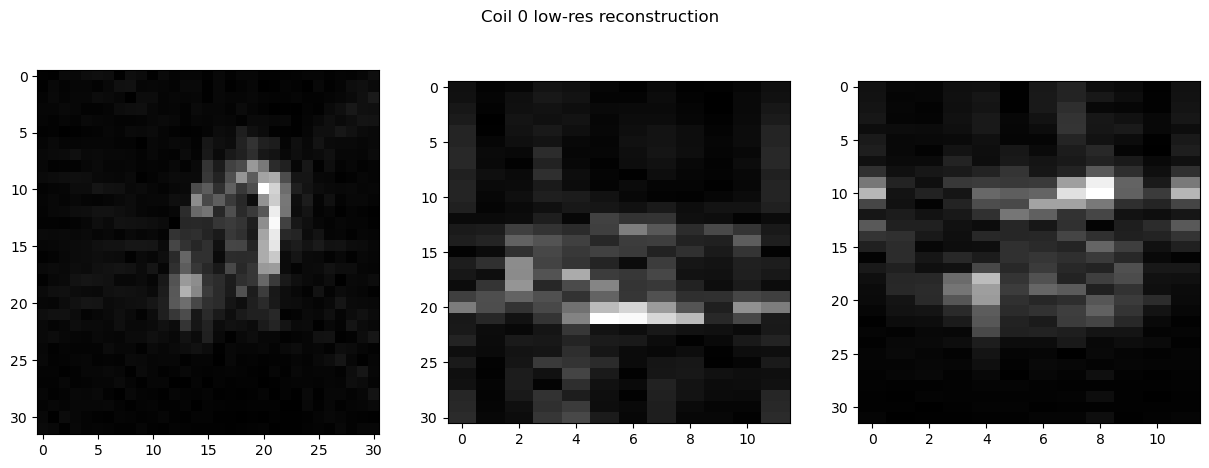

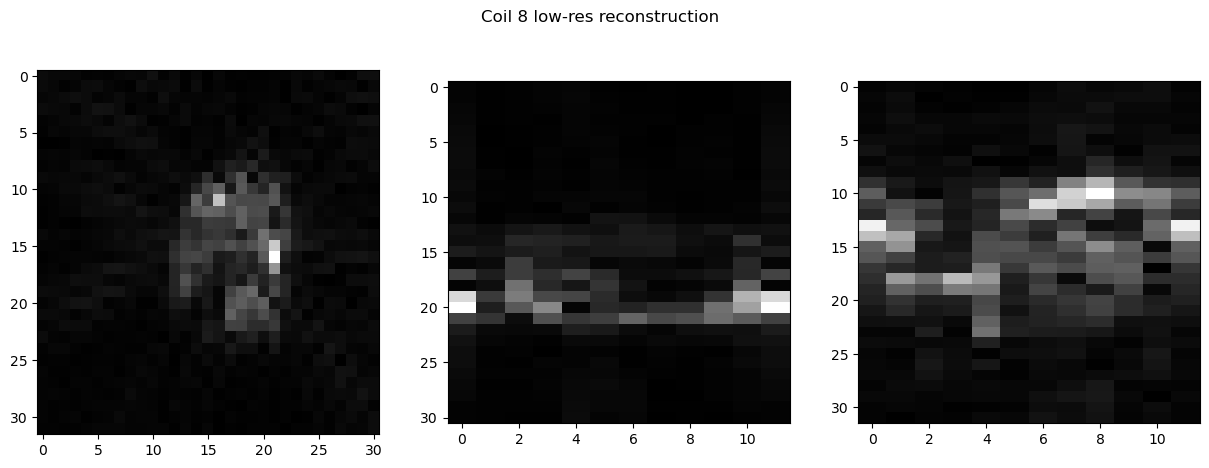

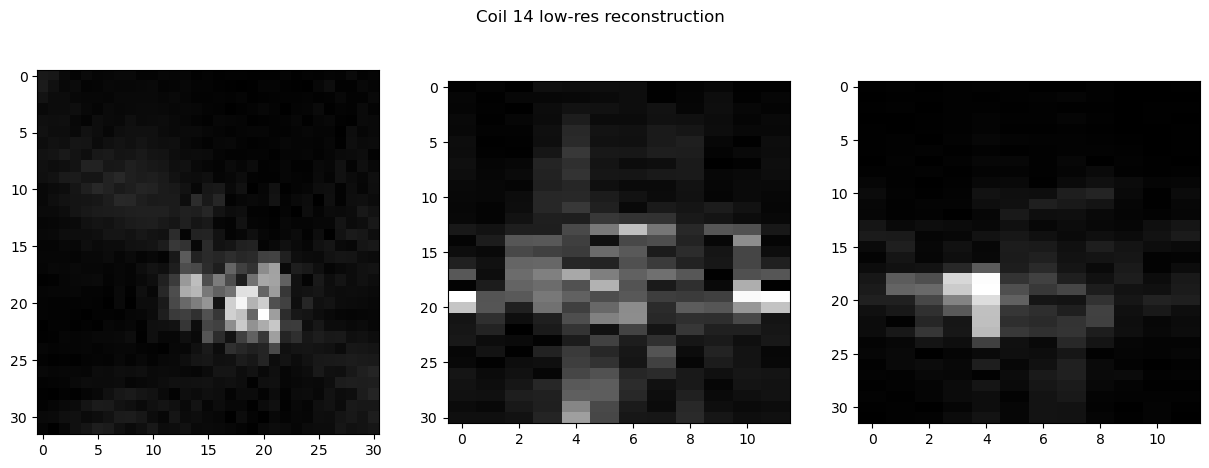

In [11]:
view_coils = [0, 8, 14]
for coil in view_coils:
    recon_plot_helpers.plot_recons_all_axes(img_grid[coil], title=f'Coil {coil} low-res reconstruction')

## 3. K-space Gridding

Using our cropped non-Cartesian data, perform a quick gridding. K-space must be Cartesian for Espirit calibration function.

In [12]:
ncoils, nslices, nspokes, nsamples = ksp_512_cropped.shape
img_shape = (nslices, nsamples, nsamples)
coord = golden_angle_coords_3d(img_shape=img_shape, num_spokes=nspokes, num_points=nsamples)

ksp_512_gridded = coil_utils.grid_kspace(ksp_512_cropped, coords=coord, img_shape=img_shape)

PipeMenonDCF:   0%|          | 0/30 [00:00<?, ?it/s]

os_shape = [15, 12, 40, 39]
ksp_gridded.shape = (15, 12, 40, 39)


## 4. Run EspiritCalib

Now with low-resolution, Cartesian k-space, run sigpy.EspiritCalib to calculate the coil sensitivity maps. Might have to experiment with calib_width, kernel_width, thresh, and crop.

In [13]:
espirit_mps_coilsens = mri.app.EspiritCalib(ksp_512_gridded, calib_width=17, kernel_width=4, thresh=0.05, crop=0.80).run()
print(f'Done calculating 2D Espirit maps, espirit_mps_coilsens.shape = {espirit_mps_coilsens.shape}')

EspiritCalib:   0%|          | 0/100 [00:00<?, ?it/s]

Done calculating 2D Espirit maps, espirit_mps_coilsens.shape = (15, 12, 40, 39)


View low-resolution maps

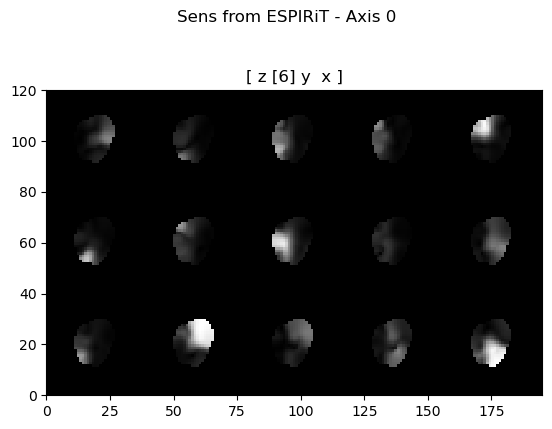

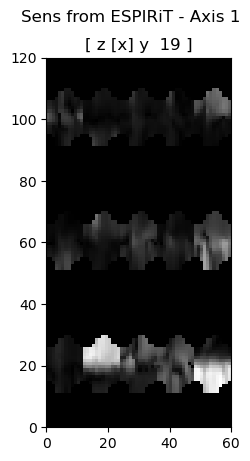

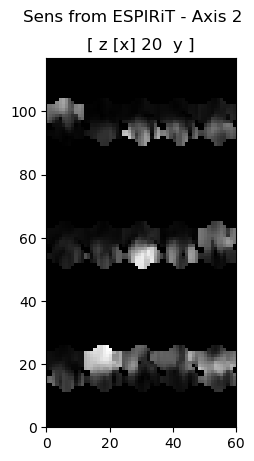

In [14]:
import sigpy.plot as pl

pl.ImagePlot(espirit_mps_coilsens, z=0, title='Sens from ESPIRiT - Axis 0')
pl.ImagePlot(espirit_mps_coilsens, x=1, y=2, z=0, title='Sens from ESPIRiT - Axis 1')
pl.ImagePlot(espirit_mps_coilsens, x=1, y=3, z=0, title='Sens from ESPIRiT - Axis 2')

## 5. Interpolate low-resolution maps to full resolution

Coil sensitivity maps will be same size as low-resolution Cartesian k-space. However, our original k-space data produces recons of a larger matrix size. Interpolate these low resolution maps to match the size of our full resolution recons

In [15]:
mps_reshaped = coil_utils.mps_reshape(espirit_mps_coilsens, oshape=(58, 512, 512))
print(f'mps_rehsaped.shape = {mps_reshaped.shape}')

3 dims
mps_rehsaped.shape = (15, 58, 512, 512)


## 6. View all: NUFFT, Espirit (low res), Espirit (high res)

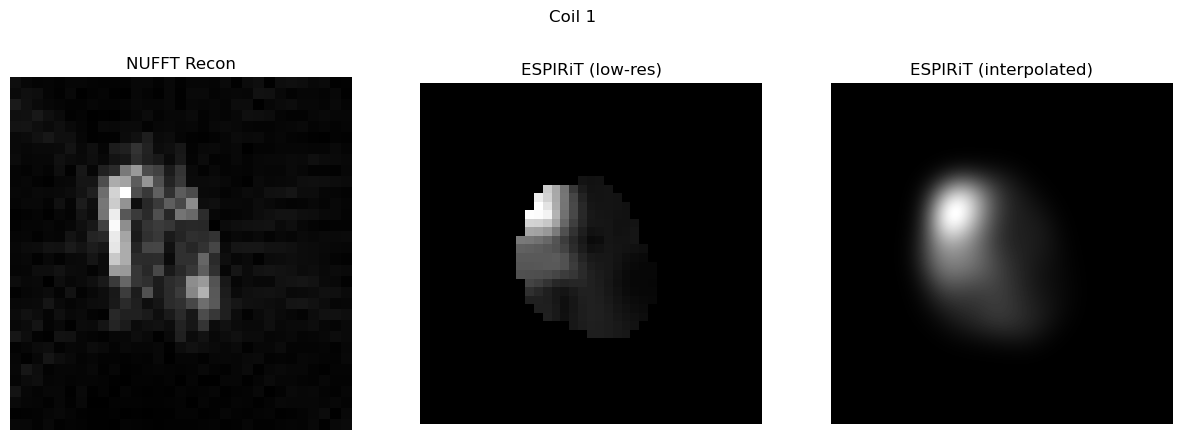

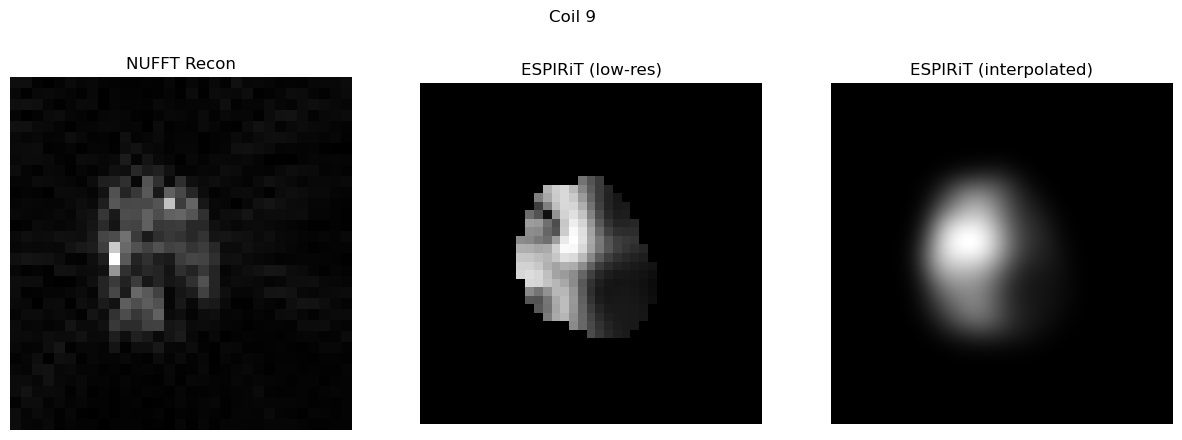

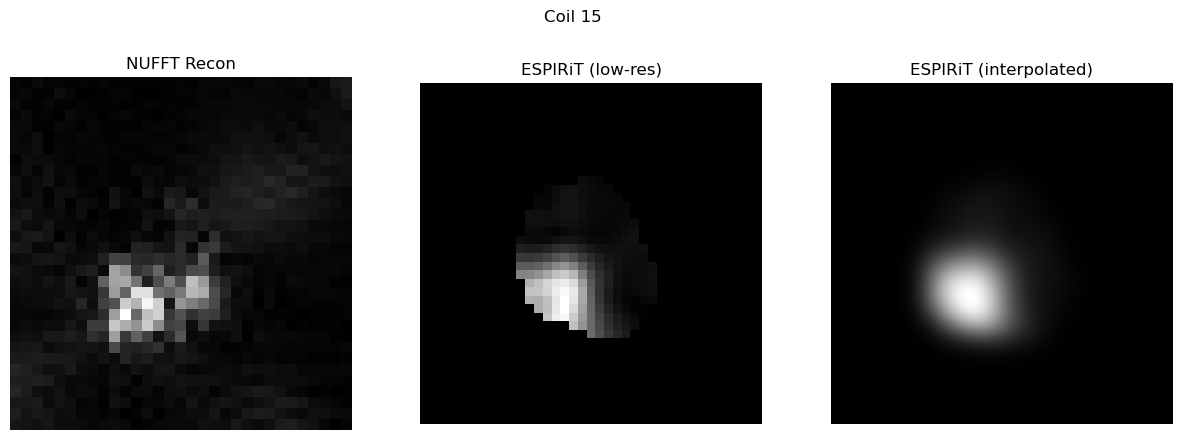

In [16]:
view_coils = [0, 8, 14]

for coil in view_coils:
    fig, axs = coil_utils.plot_all_images(img_grid, espirit_mps_coilsens, mps_reshaped, coil_idx=coil, slice_axis=0)   

In [17]:
save_data_helpers.write_pickle(mps_reshaped, "/home/lilianae/projects/naf_clean/coils/subject3_mid0283/espirit_mps_full_res_ksp_512_ungated.pkl")

Successfully saved as /home/lilianae/projects/naf_clean/coils/subject3_mid0283/espirit_mps_full_res_ksp_512_ungated.pkl
